In [1]:
#!sudo python ../setup.py develop

In [2]:
from slowfast.config.defaults import assert_and_infer_cfg
from slowfast.utils.parser import load_config, parse_args

In [3]:
import cv2
from IPython.display import clear_output

In [25]:
import time

import numpy as np
import torch
#import tqdm
from slowfast.datasets import cv2_transform
from slowfast.utils import logging
from slowfast.visualization.async_predictor import AsyncDemo, AsyncVis, draw_predictions
from slowfast.visualization.demo_loader import VideoManager
from slowfast.visualization.predictor import Predictor
from slowfast.visualization.video_visualizer import VideoVisualizer, ImgVisualizer
from slowfast.visualization.utils import process_cv2_inputs

In [5]:
import matplotlib.pyplot as plt

In [6]:
import sys
sys.path.append("/home/developer/SlowFast/tools")

In [7]:
sys.argv = [
    "tools/run_net.py",  # argv[0]는 프로그램 이름 (아무거나 넣어도 됨)
    "--cfg", "./AVA/SLOWFAST_32x2_R101_50_50.yaml",
    "--opts",
    "DEMO.ENABLE", "True",
    "DEMO.INPUT_VIDEO", "archery.mp4",       # "$INPUT" 대신 직접 경로
    "DEMO.OUTPUT_FILE", "../outputs/archery.mp4",      # "$OUTPUT" 대신 직접 경로
    "DEMO.LABEL_FILE_PATH", "../labels/ava_classids.json",
    "DEMO.DETECTRON2_CFG", "../configs/COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml",
    "DEMO.DETECTRON2_WEIGHTS", "detectron2://COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl",
    "TEST.CHECKPOINT_FILE_PATH", "../checkpoints/SLOWFAST_32x2_R101_50_50.pkl",
    #"TEST.CHECKPOINT_TYPE", "caffe2",
    "TRAIN.ENABLE", "False",
    "DETECTION.ENABLE","True",

]
args = parse_args() 

## checkpoint file
checkpoints 폴더에서 donwload `SLOWFAST_32x2_R101_50_50.pkl`
```
wget https://dl.fbaipublicfiles.com/pyslowfast/model_zoo/ava/SLOWFAST_32x2_R101_50_50.pkl
```

In [8]:
path_to_config = args.cfg_files[0]
cfg = load_config(args, path_to_config)
cfg = assert_and_infer_cfg(cfg)

## Predictor(cfg)
- SlowFast 모델을 구현함.
- SlowFast 모델일 경우 입력을 두개 path로 나눔
- fast path는 64개 frame중 32를 사용함.
- slow path는 64개 frame중 8를 사용함.
- 모델을 출력은 k400일 경우 pred의 차원 (nbatch=1, 400)인 것 같음.

In [9]:
predictor = Predictor(cfg)

missing keys: []
unexpected keys: []


In [10]:
# Set random seed from configs.
np.random.seed(cfg.RNG_SEED)
torch.manual_seed(cfg.RNG_SEED)
# Setup logging format.

common_classes = (
    cfg.DEMO.COMMON_CLASS_NAMES if len(cfg.DEMO.LABEL_FILE_PATH) != 0 else None
)

video_vis = VideoVisualizer(
    num_classes=cfg.MODEL.NUM_CLASSES,
    class_names_path=cfg.DEMO.LABEL_FILE_PATH,
    top_k=cfg.TENSORBOARD.MODEL_VIS.TOPK_PREDS,
    thres=cfg.DEMO.COMMON_CLASS_THRES,
    lower_thres=cfg.DEMO.UNCOMMON_CLASS_THRES,
    common_class_names=common_classes,
    colormap=cfg.TENSORBOARD.MODEL_VIS.COLORMAP,
    mode=cfg.DEMO.VIS_MODE,
)

In [11]:
def display_frames(frames):
    """
    display frame in frames in matplot.
    
    """
    for frame in frames:
        fig, ax = plt.subplots(figsize=(12,8))
        #image_bgr = cv2.imread(seq_info["image_filenames"][frame_idx], cv2.IMREAD_COLOR)
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax.imshow(image_rgb)
        #plt.draw()
        clear_output(wait=True)
        #
        plt.show()
        #

## VideoManager(cfg)
- "DEMO.INPUT_VIDEO"을 cv2을 통해 한번에 64개를 읽음(cfg.DATA.NUM_FRAMES=32 * cfg.DATA.SAMPLING_RATE=2)
- "DEMO.OUTPUT_FILE= ../outputs/archery.mp4"에 detection 결과를 출력함.

## video_vis.draw_one_frame
- detection의 결과에 따라 frames 64개 중 1개에 만 결과를 보여준다.


In [27]:
cfg.NUM_GPUS

1

In [30]:
frames, bboxes = task.frames, task.bboxes

In [32]:
bboxes == None

True

In [33]:
bboxes.shape[0]

AttributeError: 'NoneType' object has no attribute 'shape'

In [29]:
# Transfer the data to the current GPU device.
if isinstance(inputs, (list,)):
    for i in range(len(inputs)):
        print(f"{i} th")
        inputs[i] = inputs[i].cuda(
            device=torch.device(predictor.gpu_id), non_blocking=True
        )
else:
    inputs = inputs.cuda(
        device=torch.device(predictor.gpu_id), non_blocking=True
    )

0 th
1 th


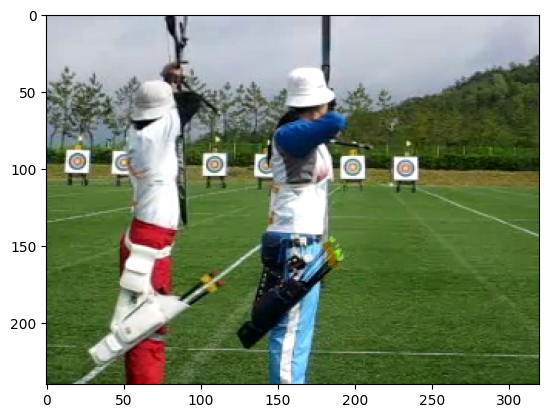

In [26]:
frame_provider = VideoManager(cfg)
frame_provider.start()

for able_to_read, task in frame_provider:
    if able_to_read:
        #task = predictor(task)
        if cfg.DETECTION.ENABLE:
            task = predictor.object_detector(task)
        frames, bboxes = task.frames, task.bboxes
        if bboxes is not None:
            bboxes = cv2_transform.scale_boxes(
                cfg.DATA.TEST_CROP_SIZE,
                bboxes,
                task.img_height,
                task.img_width,
            )
        if cfg.DEMO.INPUT_FORMAT == "BGR":
            frames = [cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in frames]

        frames = [
            cv2_transform.scale(cfg.DATA.TEST_CROP_SIZE, frame) for frame in frames
        ]
        inputs = process_cv2_inputs(frames, cfg)
        if task is None:
            time.sleep(0.02)
            print("task None")
            continue
        #img = video_vis.draw_one_frame(task.frames[32], task.action_preds)
        img = task.frames[32]
        img = img[:,:,::-1]
        plt.imshow(img)
        clear_output(wait=True)
        #
        plt.show()

    else:
        break
frame_provider.join()
frame_provider.clean()

In [22]:
len(frames)

64

In [13]:
frame_provider = VideoManager(cfg)
frame_provider.start()

for able_to_read, task in frame_provider:
    if able_to_read:
        for frame in task.frames:
            print(f"fame.shape:{frame.shape[:3]}")
    else:
        break

fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)
fame.shape:(240, 320, 3)


## draw_predictions
- detection의 결과에 따라 64개의 frame의 중간(32번째 프레임) 프레임 양쪽 $\pm 10$ 구간에 detection의 결과를 출력함.

In [14]:
frame_provider = VideoManager(cfg)
frame_provider.start()

for able_to_read, task in frame_provider:
    if able_to_read:
        task = predictor(task)
        if task is None:
            time.sleep(0.02)
            print("task None")
            continue
        
        frames = draw_predictions(task,
                                  video_vis)
        task.frames = frames
        display_frames(frames)
        frame_provider.display(task)
    else:
        break
frame_provider.join()
frame_provider.clean()

NameError: name 'model' is not defined